# Percentage,Percentile & Quartiles

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
students = pd.DataFrame({
    "Student_ID": list(range(101, 151)),

    "Student_Name": [
        "Aarav","Diya","Vihaan","Anaya","Aditya",
        "Ishita","Kabir","Meera","Aryan","Siya",
        "Vivaan","Aditi","Rohan","Sneha","Karan",
        "Priya","Rahul","Neha","Yash","Pooja",
        "Arjun","Kavya","Dev","Anika","Riya",
        "Manav","Saanvi","Harsh","Nisha","Om",
        "Tanvi","Krish","Aisha","Ved","Ritika",
        "Parth","Mahi","Reyansh","Kiara","Ayaan",
        "Sakshi","Dhruv","Ira","Rudra","Anvi",
        "Nikhil","Palak","Varun","Myra","Tanish"
    ],

    "Marks": [
        92,75,88,64,95,
        81,55,72,68,90,
        84,78,60,97,86,
        73,66,91,58,79,
        83,69,74,87,93,
        61,77,82,70,96,
        89,63,85,71,94,
        76,59,80,98,67,
        65,57,99,62,88,
        91,54,73,84,79
    ]
})

students.head()

,Student_ID,Student_Name,Marks
0,101,Aarav,92
1,102,Diya,75
2,103,Vihaan,88
3,104,Anaya,64
4,105,Aditya,95


In [5]:
students.shape

(50, 3)

In [6]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Student_ID    50 non-null     int64 
 1   Student_Name  50 non-null     object
 2   Marks         50 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.3+ KB


In [7]:
students.describe()

,Student_ID,Marks
count,50.00000,50.000000
mean,125.50000,77.560000
std,14.57738,12.816061
min,101.00000,54.000000
25%,113.25000,67.250000
50%,125.50000,78.500000
75%,137.75000,88.000000
max,150.00000,99.000000


### Percentage

    Percentage is a way of expressing a number as a part of 100. It tells us what proportion or fraction of the total a value represents.

    Formula
    
$$
\text{Percentage}=\frac{\text{Part}}{\text{Whole}}\times100
$$
     
     Example
$$
\text{Percentage}=\frac{125}{500}\times100=25\%
$$

### Percentage of Students Scoring 80 0r Abobe

In [10]:
high_score = (students["Marks"] >= 80).sum()

total_students = len(students)

percentage = (high_score / total_students) * 100

print(f"Students Scoring 80 or Above : {percentage:.2f}%")

Students Scoring 80 or Above : 46.00%


In [12]:
below_60 = (students["Marks"] < 80).sum()

percentage = (below_60 / len(students)) * 100

print(f"Students Scoring Below 80 : {percentage:.2f}%")

Students Scoring Below 80 : 54.00%


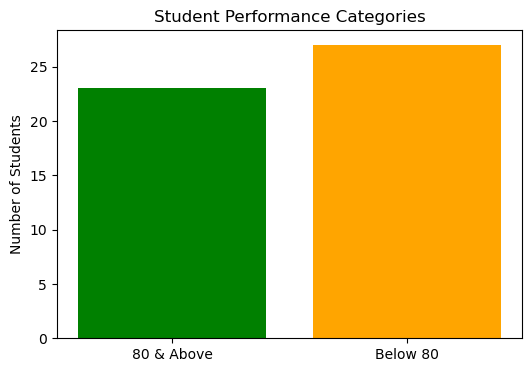

In [13]:
categories = ["80 & Above", "Below 80"]

counts = [
    (students["Marks"] >= 80).sum(),
    (students["Marks"] < 80).sum()
]

plt.figure(figsize=(6,4))

plt.bar(
    categories,
    counts,
    color=["green","orange"]
)

plt.title("Student Performance Categories")

plt.ylabel("Number of Students")

plt.show()

### Percentile
    A Percentile indicates the value below which a given percentage of observations in a dataset falls.

    It is used to compare an observation with the rest of the dataset.
    
    Percentile Position Formula
        
$$
\text{Position}=\frac{P}{100}\times(N+1)
$$
    
            where:
                P = Percentile (e.g., 25, 50, 90)
                N = Number of observations

In [48]:
p= (75/100)*(len(students['Marks'])+1)
p

38.25

### How to interpret 38.25

This means the 75th percentile lies between the 38th and 39th values after sorting the marks in ascending order.

In [50]:
sorted_marks = students["Marks"].sort_values().reset_index(drop=True)

print("38th Value :", sorted_marks.iloc[37])
print("39th Value :", sorted_marks.iloc[38])

38th Value : 88
39th Value : 89


### 25th Percentiles

In [20]:
a=students["Marks"].quantile(0.25)

print('25th Percentile Is:',a)

25th Percentile Is: 67.25


### 50th Percentile(Median)


In [22]:
b=students["Marks"].quantile(0.50)

print('50th Percentile Is:',b)

50th Percentile Is: 78.5


### 75th Percentile

In [23]:
c=students["Marks"].quantile(0.75)

print('75th Percentile Is:',c)

75th Percentile Is: 88.0


### 90th Percentile

In [29]:
d=students["Marks"].quantile(0.90)

print('90th Percentile Is:',d)

90th Percentile Is: 94.1


### Using Numpy

In [30]:
import numpy as np

print(f"25th Percentile : {np.percentile(students['Marks'],25)}")

print(f"50th Percentile : {np.percentile(students['Marks'],50)}")

print(f"75th Percentile : {np.percentile(students['Marks'],75)}")

print(f"90th Percentile : {np.percentile(students['Marks'],90)}")

25th Percentile : 67.25
50th Percentile : 78.5
75th Percentile : 88.0
90th Percentile : 94.1


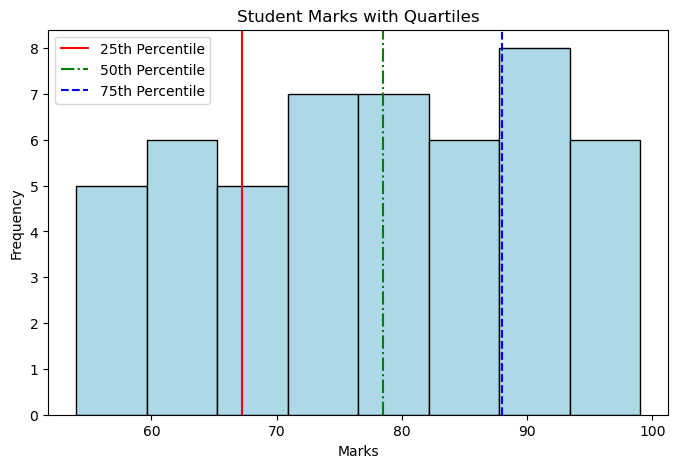

In [42]:
p25 = np.percentile(students["Marks"],25)
p50 = np.percentile(students["Marks"],50)
p75 = np.percentile(students["Marks"],75)

plt.figure(figsize=(8,5))

plt.hist(
    students["Marks"],
    bins=8,
    color="lightblue",
    edgecolor="black"
)

plt.axvline(p25,color="red",linestyle="solid",label="25th Percentile")
plt.axvline(p50,color="green",linestyle="-.",label="50th Percentile")
plt.axvline(p75,color="blue",linestyle="--",label="75th Percentile")

plt.title("Student Marks with Quartiles")

plt.xlabel("Marks")

plt.ylabel("Frequency")

plt.legend()

plt.show()

### Interquartile Range (IQR)
    The Interquartile Range (IQR) measures the spread of the middle 50% of a dataset. It is the difference between the Third Quartile (Q3) and the First Quartile (Q1).

    Unlike the Range, IQR ignores the lowest 25% and highest 25% of the data, making it less affected by outliers.

    Formula
$$
IQR = Q_3 - Q_1
$$	

            Where
                Q1 (First Quartile) = 25th Percentile
                Q3 (Third Quartile) = 75th Percentile   

In [70]:
# Sorted Marks
m=np.array([40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95])

#Suppose:
Q1=np.percentile(m,25)

Q3=np.percentile(m,75)

IQR=Q3 - Q1



print(IQR)

#Interpretation: The middle 50% of student marks are spread across 27.5 marks.

27.5


In [72]:
Q1 = students["Marks"].quantile(0.25)

Q3 = students["Marks"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 : {Q1}")
print(f"Q3 : {Q3}")
print(f"\n IQR : {IQR}")

Q1 : 67.25
Q3 : 88.0

IQR : 20.75


### Interpretation
    A small IQR indicates that the middle 50% of student marks are close together, showing consistent performance.
    
    A large IQR indicates greater variation among the middle 50% of students.

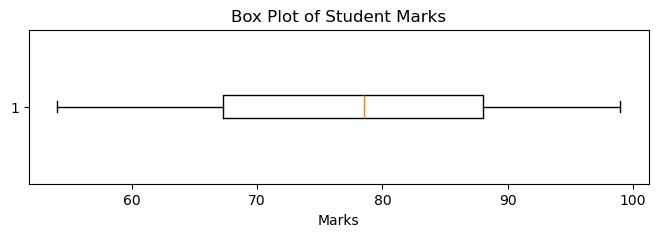

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))

plt.boxplot(students["Marks"], vert=False)

plt.title("Box Plot of Student Marks")

plt.xlabel("Marks")

plt.show()

### Quartiles
    Quartiles divide a sorted dataset into four equal parts.

    Each quartile contains 25% of the observations.

    Types of Quartiles
        Q1 (First Quartile) → 25th Percentile
                25% of obeservations lie below it
        
        Q2 (Second Quartile) → 50th Percentile 
                This is the Median
        
        Q3 (Third Quartile) → 75th Percentile
                75% od data below it.

In [74]:
Q1 = students["Marks"].quantile(0.25)

Q2 = students["Marks"].quantile(0.50)

Q3 = students["Marks"].quantile(0.75)

print(f"Q1 (25th Percentile): {Q1}")
print(f"Q2 (Median): {Q2}")
print(f"Q3 (75th Percentile): {Q3}")

Q1 (25th Percentile): 67.25
Q2 (Median): 78.5
Q3 (75th Percentile): 88.0


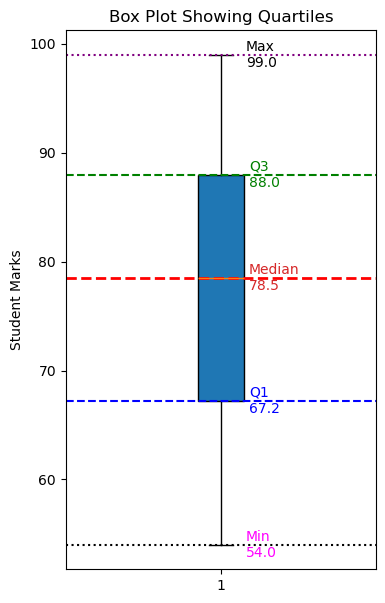

In [138]:

Min = students["Marks"].min()
Q1 = students["Marks"].quantile(0.25)
Q2 = students["Marks"].quantile(0.50)
Q3 = students["Marks"].quantile(0.75)
Max = students["Marks"].max()

plt.figure(figsize=(4,7))

plt.boxplot(
    students["Marks"],
    vert=True,
    patch_artist=True
)

plt.title("Box Plot Showing Quartiles")

plt.ylabel("Student Marks")


plt.axhline(minimum, color="black", linestyle=":", label=f"Min = {minimum}")
plt.axhline(Q1, color="blue", linestyle="--", label=f"Q1 = {Q1:.1f}")
plt.axhline(Q2, color="red", linestyle="--", linewidth=2, label=f"Median = {Q2:.1f}")
plt.axhline(Q3, color="green", linestyle="--", label=f"Q3 = {Q3:.1f}")
plt.axhline(maximum, color="purple", linestyle=":", label=f"Max = {maximum}")

# Add labels at quartiles
plt.text(1.08, Max, f"Max\n{Max:.1f}", color="black", va="center")
plt.text(1.09, Q1, f"Q1\n{Q1:.1f}", color="blue", va="center")
plt.text(1.09, Q2, f"Median\n{Q2:.1f}", color="C23", va="center")
plt.text(1.09, Q3, f"Q3\n{Q3:.1f}", color="green", va="center")

plt.text(1.08, Min, f"Min\n{Min:.1f}", color="magenta", va="center")

plt.show()